In [1]:
# Inflation Regime Detection

Inflation regime detection is one of the powerful macro intelligence tool. It is considered as a powerful tool because its specifically  distinguishing between low and high inflation environtments. Regime detection itself is a powerful analytical tool because economic, behavioral and market dynamics change fundamentally between them.

The purpose of this analytics is,
1. Analyze the trend inflation on each country
2. Comparing the inflation on each country
3. Analyze the CPI Distribution to find the stable and wild one
4. Analyze the volatility using standard deviation of each country

The method will be used in this analytics are K-Means and Regression

### Import Library

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

%matplotlib inline

### Data Ingestion

In [2]:
file_path = "datasets/imf_cpi.csv"
df = pd.read_csv(file_path)
df.head(5)

,DATASET,SERIES_CODE,OBS_MEASURE,COUNTRY,INDEX_TYPE,COICOP_1999,TYPE_OF_TRANSFORMATION,FREQUENCY,SCALE,2014,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,IMF.STA:CPI(5.0.0),USA.CPI.CP10.IX.A,OBS_VALUE,United States,Consumer price index (CPI),Education,Index,Annual,Units,115.965034,...,123.531048,126.414146,129.312862,133.064108,135.681600,137.600269,142.521649,145.941673,150.605637,NaN
1,IMF.STA:CPI(5.0.0),USA.CPI.CP02.IX.A,OBS_VALUE,United States,Consumer price index (CPI),"Alcoholic beverages, tobacco and narcotics",Index,Annual,Units,108.171260,...,112.544172,116.500510,119.542920,123.429100,127.641880,133.336814,140.365196,147.078314,153.659773,NaN
2,IMF.STA:CPI(5.0.0),USA.CPI.CP10.POP_PCH_PA_PT.A,OBS_VALUE,United States,Consumer price index (CPI),Education,"Period average, Period-over-period percent change",Annual,Units,3.278435,...,2.808177,2.333906,2.293032,2.900907,1.967091,1.414096,3.576577,2.399653,3.195773,NaN
3,IMF.STA:CPI(5.0.0),USA.CPI.CP10.YOY_PCH_PA_PT.A,OBS_VALUE,United States,Consumer price index (CPI),Education,"Period average, Year-over-year (YOY) percent c...",Annual,Units,3.278435,...,2.808177,2.333906,2.293032,2.900907,1.967091,1.414096,3.576577,2.399653,3.195773,NaN
4,IMF.STA:CPI(5.0.0),USA.CPI.CP01.YOY_PCH_PA_PT.A,OBS_VALUE,United States,Consumer price index (CPI),Food and non-alcoholic beverages,"Period average, Year-over-year (YOY) percent c...",Annual,Units,2.407605,...,-1.325349,-0.202182,0.455565,0.885131,3.505030,3.469165,11.438885,4.944269,1.166140,NaN


As we have imported the data. So shape method will show us the dimension of the dataset.

In [3]:
print("Full train dataset shape is {}".format(df.shape))

Full train dataset shape is (884, 21)


This IMF CPI consist of 884 rows and 21 columns

### Data Preprocessing

In [4]:
df.dtypes

DATASET                    object
SERIES_CODE                object
OBS_MEASURE                object
COUNTRY                    object
INDEX_TYPE                 object
COICOP_1999                object
TYPE_OF_TRANSFORMATION     object
FREQUENCY                  object
SCALE                      object
2014                      float64
2015                      float64
2016                      float64
2017                      float64
2018                      float64
2019                      float64
2020                      float64
2021                      float64
2022                      float64
2023                      float64
2024                      float64
2025                      float64
dtype: object

In [5]:
object_cols = df.select_dtypes(include=['object']).columns
print("Categorical variables:", len(object_cols))

int_ = df.select_dtypes(include=['int64']).columns
print("Integer variables:", len(int_))

fl_cols = df.select_dtypes(include=['float64']).columns
print("Float variables:", len(fl_cols))


Categorical variables: 9
Integer variables: 0
Float variables: 12


### Initial EDA

In [6]:
df.info()
df.describe()
df.isna().sum()

# Filter and Copy Data
data = df[
    (df['TYPE_OF_TRANSFORMATION'] == 'Period average, Year-over-year (YOY) percent change') &
    (df['FREQUENCY'] == 'Annual')
].copy()

data.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 884 entries, 0 to 883
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   DATASET                 884 non-null    object 
 1   SERIES_CODE             884 non-null    object 
 2   OBS_MEASURE             884 non-null    object 
 3   COUNTRY                 884 non-null    object 
 4   INDEX_TYPE              884 non-null    object 
 5   COICOP_1999             884 non-null    object 
 6   TYPE_OF_TRANSFORMATION  884 non-null    object 
 7   FREQUENCY               884 non-null    object 
 8   SCALE                   884 non-null    object 
 9   2014                    715 non-null    float64
 10  2015                    726 non-null    float64
 11  2016                    748 non-null    float64
 12  2017                    761 non-null    float64
 13  2018                    787 non-null    float64
 14  2019                    718 non-null    fl

,DATASET,SERIES_CODE,OBS_MEASURE,COUNTRY,INDEX_TYPE,COICOP_1999,TYPE_OF_TRANSFORMATION,FREQUENCY,SCALE,2014,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
3,IMF.STA:CPI(5.0.0),USA.CPI.CP10.YOY_PCH_PA_PT.A,OBS_VALUE,United States,Consumer price index (CPI),Education,"Period average, Year-over-year (YOY) percent c...",Annual,Units,3.278435,...,2.808177,2.333906,2.293032,2.900907,1.967091,1.414096,3.576577,2.399653,3.195773,NaN
4,IMF.STA:CPI(5.0.0),USA.CPI.CP01.YOY_PCH_PA_PT.A,OBS_VALUE,United States,Consumer price index (CPI),Food and non-alcoholic beverages,"Period average, Year-over-year (YOY) percent c...",Annual,Units,2.407605,...,-1.325349,-0.202182,0.455565,0.885131,3.505030,3.469165,11.438885,4.944269,1.166140,NaN
5,IMF.STA:CPI(5.0.0),USA.CPI.CP08.YOY_PCH_PA_PT.A,OBS_VALUE,United States,Consumer price index (CPI),Communication,"Period average, Year-over-year (YOY) percent c...",Annual,Units,-0.049137,...,-0.550631,-5.483102,-1.265205,-0.536588,2.362062,1.817034,-0.430050,0.180603,-1.353980,NaN
10,IMF.STA:CPI(5.0.0),USA.CPI.CP03.YOY_PCH_PA_PT.A,OBS_VALUE,United States,Consumer price index (CPI),Clothing and footwear,"Period average, Year-over-year (YOY) percent c...",Annual,Units,0.395169,...,-0.022691,-0.373311,0.327138,-0.915604,-4.453169,2.394024,5.415234,2.684161,0.952374,NaN
12,IMF.STA:CPI(5.0.0),USA.CPI.CP04.YOY_PCH_PA_PT.A,OBS_VALUE,United States,Consumer price index (CPI),"Housing, water, electricity, gas and other fuels","Period average, Year-over-year (YOY) percent c...",Annual,Units,2.969430,...,2.847277,3.457183,3.162829,3.040952,2.588173,3.020479,6.895680,6.943748,5.105299,NaN


Check the new shape again

In [7]:
print("New dataset shape is {}".format(data.shape))

New dataset shape is (241, 21)


### Data Cleaning and Aggregation

In [8]:
cols_to_keep = ['COUNTRY'] + [col for col in df.columns if str(col).isdigit()]
data = data[cols_to_keep]
data.head(5)

,COUNTRY,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
3,United States,3.278435,3.614707,2.808177,2.333906,2.293032,2.900907,1.967091,1.414096,3.576577,2.399653,3.195773,NaN
4,United States,2.407605,1.167711,-1.325349,-0.202182,0.455565,0.885131,3.505030,3.469165,11.438885,4.944269,1.166140,NaN
5,United States,-0.049137,-1.700052,-0.550631,-5.483102,-1.265205,-0.536588,2.362062,1.817034,-0.430050,0.180603,-1.353980,NaN
10,United States,0.395169,-0.998736,-0.022691,-0.373311,0.327138,-0.915604,-4.453169,2.394024,5.415234,2.684161,0.952374,NaN
12,United States,2.969430,2.331401,2.847277,3.457183,3.162829,3.040952,2.588173,3.020479,6.895680,6.943748,5.105299,NaN


Handle Missing

In [9]:
data.replace("no data", np.nan, inplace=True)
data.head(5)

,COUNTRY,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
3,United States,3.278435,3.614707,2.808177,2.333906,2.293032,2.900907,1.967091,1.414096,3.576577,2.399653,3.195773,NaN
4,United States,2.407605,1.167711,-1.325349,-0.202182,0.455565,0.885131,3.505030,3.469165,11.438885,4.944269,1.166140,NaN
5,United States,-0.049137,-1.700052,-0.550631,-5.483102,-1.265205,-0.536588,2.362062,1.817034,-0.430050,0.180603,-1.353980,NaN
10,United States,0.395169,-0.998736,-0.022691,-0.373311,0.327138,-0.915604,-4.453169,2.394024,5.415234,2.684161,0.952374,NaN
12,United States,2.969430,2.331401,2.847277,3.457183,3.162829,3.040952,2.588173,3.020479,6.895680,6.943748,5.105299,NaN


Rename Column

In [10]:
data.rename(columns={data.columns[0]: 'Country'}, inplace=True)
data.head()

,Country,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
3,United States,3.278435,3.614707,2.808177,2.333906,2.293032,2.900907,1.967091,1.414096,3.576577,2.399653,3.195773,NaN
4,United States,2.407605,1.167711,-1.325349,-0.202182,0.455565,0.885131,3.505030,3.469165,11.438885,4.944269,1.166140,NaN
5,United States,-0.049137,-1.700052,-0.550631,-5.483102,-1.265205,-0.536588,2.362062,1.817034,-0.430050,0.180603,-1.353980,NaN
10,United States,0.395169,-0.998736,-0.022691,-0.373311,0.327138,-0.915604,-4.453169,2.394024,5.415234,2.684161,0.952374,NaN
12,United States,2.969430,2.331401,2.847277,3.457183,3.162829,3.040952,2.588173,3.020479,6.895680,6.943748,5.105299,NaN


Wide to Long

In [11]:
data_long = data.melt(
    id_vars=['Country'],
    var_name='Year',
    value_name='Inflation_YOY'
)

Convert Type Data

In [12]:
data_long['Year'] = pd.to_numeric(data_long['Year'], errors='coerce')
data_long['Inflation_YOY'] = pd.to_numeric(data_long['Inflation_YOY'], errors='coerce')

Drop Missing

In [13]:
data_long = data_long.dropna()

In [14]:
data_long.head(4)

,Country,Year,Inflation_YOY
0,United States,2014,3.278435
1,United States,2014,2.407605
2,United States,2014,-0.049137
3,United States,2014,0.395169


In [15]:
data_long = (
    data_long.groupby(['Country', 'Year'])['Inflation_YOY']
    .mean()
    .reset_index()
)

print(data_long[data_long['Country'] == "Argentina"])

     Country  Year  Inflation_YOY
0  Argentina  2018      33.594068
1  Argentina  2019      51.922107
2  Argentina  2020      41.320904
3  Argentina  2021      45.824785
4  Argentina  2022      69.130496
5  Argentina  2023     129.759611
6  Argentina  2024     226.218189
7  Argentina  2025      45.207520


### Add Region

In [16]:
# Add Region
region_map = {
    'United States': 'North America',
    'Canada': 'North America',
    'Mexico': 'North America',
    'Argentina': 'South America',
    'Brazil': 'South America',
    'Chile': 'South America',
    'France': 'Europe',
    'Germany': 'Europe',
    'United Kingdom': 'Europe',
    'Russian Federation': 'Europe',
    'Türkiye, Republic of': 'Europe',
    "China, People's Republic of": 'Asia',
    'India': 'Asia',
    'Indonesia': 'Asia',
    'Japan': 'Asia',
    'Saudi Arabia': 'Asia',
    'Egypt, Arab Republic of': 'Africa',
    'Kenya': 'Africa',
    'Nigeria': 'Africa',
    'South Africa': 'Africa',
    'Australia': 'Oceania',
    'New Zealand': 'Oceania',
}

data_long['Region'] = data_long['Country'].map(region_map)

# Reorder columns
data_long = data_long[['Country', 'Region', 'Year', 'Inflation_YOY']]

# Sanity check
print(data_long['Region'].isna().sum(), "unmapped countries")
data_long.head(4)

0 unmapped countries


,Country,Region,Year,Inflation_YOY
0,Argentina,South America,2018,33.594068
1,Argentina,South America,2019,51.922107
2,Argentina,South America,2020,41.320904
3,Argentina,South America,2021,45.824785


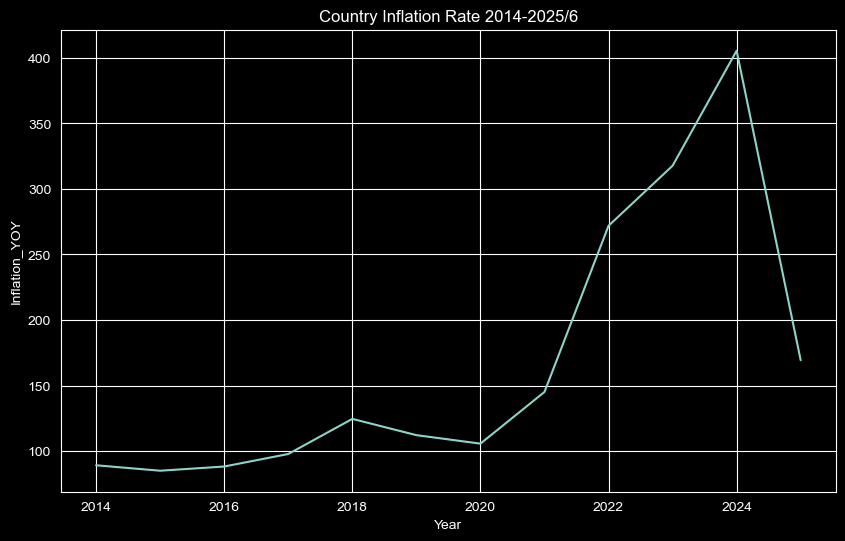

In [17]:

plt.figure(figsize=(10, 6))
data_long.groupby('Year')['Inflation_YOY'].sum().plot()
plt.xlabel('Year')
plt.ylabel('Inflation_YOY')
plt.title('Country Inflation Rate 2014-2025/6')
plt.show()


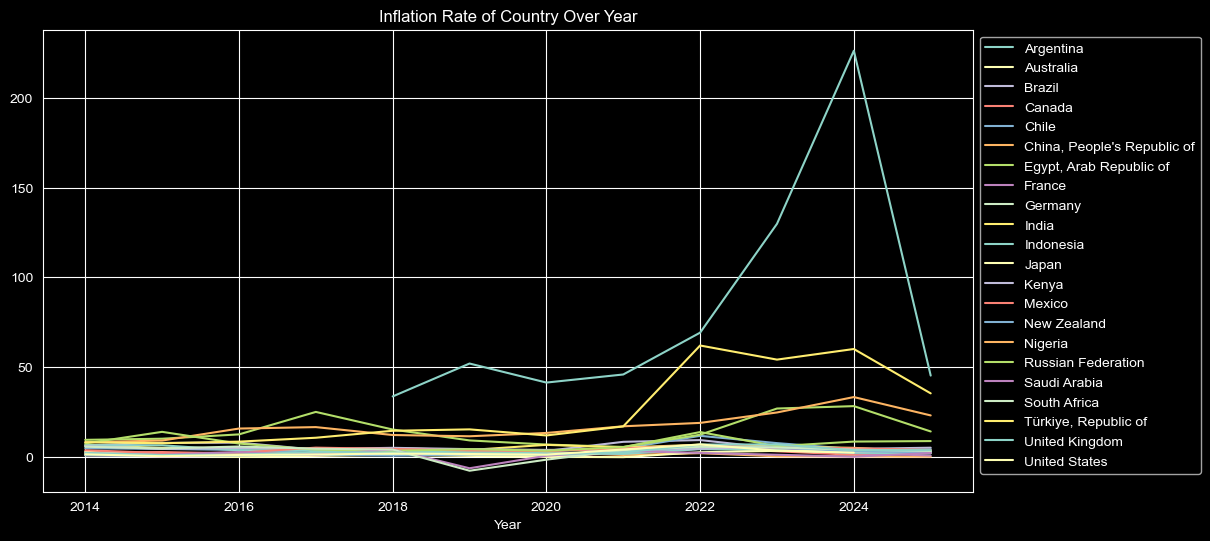

In [18]:
data_long.groupby(['Year', 'Country'])['Inflation_YOY'].sum().unstack().plot(figsize=(12, 6))
plt.title('Inflation Rate of Country Over Year')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()